# DQ3 — Robustezza al vento e Domain Randomization (su SAC)

Questo notebook analizza i risultati della terza domanda di ricerca del progetto StableHover. Non addestra né valuta modelli: legge gli artefatti già prodotti dagli script del progetto e ne ricava le figure e le tabelle finali, esportandole in `results/`.

La provenienza dei dati è la seguente. Il confronto oppone due policy che differiscono solo per la presenza di vento in addestramento: la **Policy A** è la SAC con reward shaping λ=0.1 addestrata in aria calma, vincitrice della Domanda 2 (riusata da `experiments/dq2/`); la **Policy B** è la stessa SAC con reward shaping λ=0.1 addestrata con vento stocastico iniettato durante il training (*domain randomization*), prodotta da `src/train.py` con l'ambiente `HoverAviaryWind` (in `src/envs/`), orchestrato da `scripts/run_dq3_policyB.sh`. La valutazione di robustezza è prodotta da `src/evaluate.py` su cinque intensità di vento crescenti e i riepiloghi per run sono raccolti da `scripts/aggregate_dq3.py` nel file `results/tables/dq3_robustness.csv`, da cui questo notebook parte. Il funzionamento dettagliato di ciascuno script è documentato nel `README.md`.

**Domanda di ricerca 3 (Robustezza e Domain Randomization):** il modello ottimizzato per la fluidità (vincitore Domanda 2) è in grado di resistere a turbolenze esterne stocastiche (vento) introdotte in fase di valutazione, o è necessario addestrare una nuova policy iniettando disturbi fisici casuali durante il training per evitare la perdita di assetto?

Il vento è modellato come forza orizzontale non osservata dalla policy, generata da due processi di Ornstein-Uhlenbeck indipendenti sulle componenti Fx e Fy, la cui intensità è espressa dal parametro `wind_mag` (deviazione standard della forza in frazione del peso del drone). La Policy B è addestrata a `wind_mag`=0.08; entrambe le policy sono valutate su `wind_mag` ∈ {0.02, 0.05, 0.08, 0.12, 0.15}, con condizioni iniziali e sequenze di vento identiche per costruzione (stesso seme). I livelli oltre 0.08 sono *out-of-distribution* per la Policy B, che a quelle intensità opera su venti mai visti in addestramento.

## Setup e percorsi

La cella seguente importa le librerie di analisi e definisce i percorsi del progetto a partire dalla posizione del notebook, così da funzionare indipendentemente dalla cartella di lavoro. La verifica finale conferma che il file aggregato della valutazione DQ3 sia raggiungibile prima di procedere.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TAB  = ROOT / "results" / "tables"
FIG  = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

WIND_TRAIN_B = 0.08   # vento di training della Policy B: separa in-distribution da out-of-distribution
CSV = TAB / "dq3_robustness.csv"
print("ROOT:", ROOT)
print("CSV trovato:", CSV.exists())

ROOT: /Users/lucabellu/drone-rl
CSV trovato: True


## 1. Metriche e aggregazione

La robustezza è misurata su due grandezze, per ciascuna policy e intensità di vento. Il **Crash Rate** è la frazione di episodi in cui il drone esce dall'inviluppo di volo sicuro; è la metrica primaria della domanda, che riguarda la perdita di assetto sotto turbolenza. Il **ritorno medio** di valutazione fornisce un secondo asse indipendente dal Crash Rate: un ritorno alto indica che il drone non solo sopravvive, ma resta vicino al target mentre lo fa. In appoggio si riporta anche lo **Spin Rate**, la frazione di episodi in cui il drone resta in volo ma ruota su sé stesso (l'avvitamento già osservato nella Domanda 2), che caratterizza il modo di fallimento residuo.

La cella seguente carica i risultati dei 30 esperimenti di valutazione (2 policy × 3 seed × 5 intensità di vento) e li aggrega per policy e intensità, calcolando media e deviazione standard sui tre semi di addestramento. La deviazione standard misura quanto l'esito dipenda dal seme.

In [2]:
df = pd.read_csv(CSV)

agg = (df.groupby(["policy", "wind_mag"])
         .agg(crash_mean=("crash_pct", "mean"), crash_std=("crash_pct", "std"),
              spin_mean=("spin_pct", "mean"),  spin_std=("spin_pct", "std"),
              ret_mean=("mean_return", "mean"), ret_std=("mean_return", "std"))
         .reset_index())
agg

,policy,wind_mag,crash_mean,crash_std,spin_mean,spin_std,ret_mean,ret_std
0,A,0.02,0.000000,0.000000,0.000000,0.000000,482.223100,0.729208
1,A,0.05,8.333333,3.511885,12.333333,5.507571,444.907600,7.274470
2,A,0.08,51.666667,10.503968,24.666667,1.154701,316.773400,14.417593
3,A,0.12,91.666667,4.041452,6.333333,2.516611,191.982933,9.716970
4,A,0.15,97.666667,1.527525,2.000000,1.732051,150.064633,5.833762
5,B,0.02,0.000000,0.000000,0.000000,0.000000,483.458400,0.440703
6,B,0.05,0.000000,0.000000,0.000000,0.000000,483.370733,0.424488
7,B,0.08,0.000000,0.000000,0.000000,0.000000,483.006367,0.522765
8,B,0.12,6.000000,2.000000,14.333333,3.785939,463.276067,3.873803
9,B,0.15,27.666667,9.018500,25.666667,3.214550,404.942233,19.474358


## 2. Crash Rate in funzione dell'intensità del vento

La figura seguente è il risultato principale della Domanda 3: le due curve di robustezza, con banda pari a ± una deviazione standard sui tre semi. La linea verticale tratteggiata segna il vento di addestramento della Policy B (`wind_mag`=0.08); alla sua destra la Policy B opera su intensità mai viste in training, per cui quella porzione della curva misura la generalizzazione *out-of-distribution*.

Salvato: /Users/lucabellu/drone-rl/results/figures/dq3_crashrate_vs_wind.png


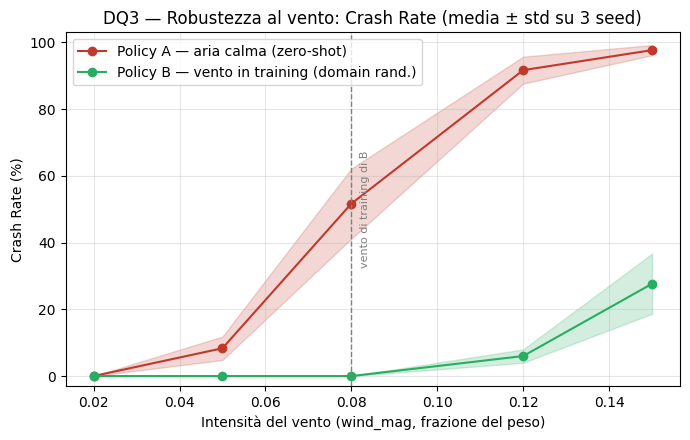

In [3]:
colors = {"A": "#c0392b", "B": "#27ae60"}
labels = {"A": "Policy A — aria calma (zero-shot)",
          "B": "Policy B — vento in training (domain rand.)"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for pol in ["A", "B"]:
    sub = agg[agg["policy"] == pol].sort_values("wind_mag")
    ax.plot(sub["wind_mag"], sub["crash_mean"], "o-", color=colors[pol], label=labels[pol])
    ax.fill_between(sub["wind_mag"], sub["crash_mean"] - sub["crash_std"],
                    sub["crash_mean"] + sub["crash_std"], color=colors[pol], alpha=0.2)

ax.axvline(WIND_TRAIN_B, ls="--", color="gray", lw=1)
ax.text(WIND_TRAIN_B + 0.002, 50, "vento di training di B", rotation=90,
        va="center", ha="left", fontsize=8, color="gray")
ax.set_xlabel("Intensità del vento (wind_mag, frazione del peso)")
ax.set_ylabel("Crash Rate (%)")
ax.set_title("DQ3 — Robustezza al vento: Crash Rate (media ± std su 3 seed)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout()
out = FIG / "dq3_crashrate_vs_wind.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Salvato:", out)
plt.show()

## 3. Ritorno medio in funzione dell'intensità del vento

La cella seguente conferma la robustezza su un asse indipendente dal Crash Rate: a parità di vento, quanto ritorno di valutazione mantiene ciascuna policy. La lettura congiunta delle due figure distingue il "non schiantarsi" dal "volare bene": una policy può sopravvivere restando lontana dal target, e il ritorno rende visibile questa differenza.

Salvato: /Users/lucabellu/drone-rl/results/figures/dq3_return_vs_wind.png


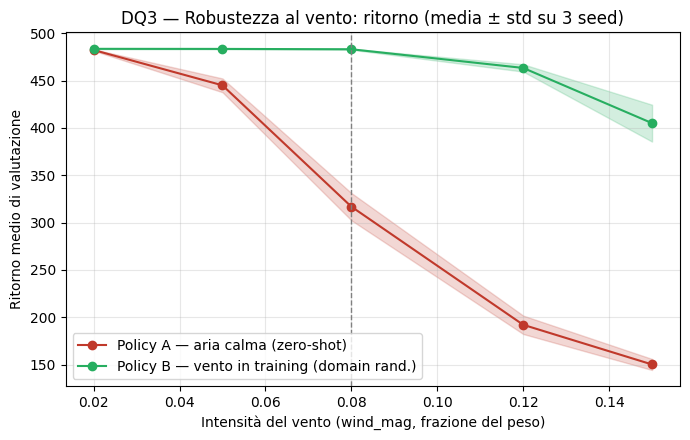

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for pol in ["A", "B"]:
    sub = agg[agg["policy"] == pol].sort_values("wind_mag")
    ax.plot(sub["wind_mag"], sub["ret_mean"], "o-", color=colors[pol], label=labels[pol])
    ax.fill_between(sub["wind_mag"], sub["ret_mean"] - sub["ret_std"],
                    sub["ret_mean"] + sub["ret_std"], color=colors[pol], alpha=0.2)

ax.axvline(WIND_TRAIN_B, ls="--", color="gray", lw=1)
ax.set_xlabel("Intensità del vento (wind_mag, frazione del peso)")
ax.set_ylabel("Ritorno medio di valutazione")
ax.set_title("DQ3 — Robustezza al vento: ritorno (media ± std su 3 seed)")
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout()
out = FIG / "dq3_return_vs_wind.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Salvato:", out)
plt.show()

## 4. Sintesi quantitativa

La cella seguente esporta il Crash Rate in due tabelle salvate in `results/tables/`: una versione completa con media e deviazione standard di Crash Rate, Spin Rate e ritorno per ogni combinazione policy–intensità, e una versione sintetica nel formato "media ± std" pivottata per intensità di vento, pensata per l'inserimento diretto nella presentazione.

In [5]:
agg.to_csv(TAB / "dq3_robustness_summary.csv", index=False)

piv = agg.assign(cell=agg["crash_mean"].round(1).astype(str) + " ± " + agg["crash_std"].round(1).astype(str))
piv = piv.pivot(index="wind_mag", columns="policy", values="cell")
piv.to_csv(TAB / "dq3_crashrate_table.csv")
print("Salvate 2 tabelle in results/tables/")
piv

Salvate 2 tabelle in results/tables/


policy,A,B
wind_mag,,
0.02,0.0 ± 0.0,0.0 ± 0.0
0.05,8.3 ± 3.5,0.0 ± 0.0
0.08,51.7 ± 10.5,0.0 ± 0.0
0.12,91.7 ± 4.0,6.0 ± 2.0
0.15,97.7 ± 1.5,27.7 ± 9.0


## 5. Verdetto DQ3

**Domanda di ricerca:** il modello ottimizzato per la fluidità resiste a turbolenze stocastiche introdotte solo in valutazione, o è necessario iniettare disturbi fisici casuali durante il training?

**Risposta: la robustezza zero-shot non è sufficiente; il domain randomization in training è necessario e sufficiente a ottenerla.**

- **Zero-shot (Policy A):** il modello fluido addestrato in aria calma perde l'assetto in modo sistematico già a vento moderato (Crash Rate ~52% a `wind_mag`=0.08) e collassa a vento forte (~98% a 0.15). La sola ottimizzazione per la fluidità non conferisce robustezza al vento.
- **Domain randomization (Policy B):** iniettare il vento in addestramento azzera il Crash Rate fino al vento di training (0% fino a 0.08) e mantiene la robustezza a intensità superiori mai viste (~6% e ~28% a 0.12 e 0.15, contro ~92% e ~98% della Policy A).
- **Ritorno sotto vento:** a parità di intensità la Policy B mantiene ritorni nettamente più alti (a 0.12: ~463 contro ~192), cioè non solo schianta meno ma vola meglio quando sopravvive: la robustezza si conferma su un secondo asse indipendente dal Crash Rate.

**Interpretazione.** Il vento richiede al drone di inclinarsi per generare una spinta orizzontale che compensi la forza esterna. La policy addestrata in aria calma non ha mai incontrato questa esigenza e reagisce in modo inadeguato quando la forza diventa significativa rispetto all'autorità di comando disponibile. Esponendo la policy a raffiche stocastiche variabili durante il training, il domain randomization le fa apprendere una strategia di compensazione che generalizza anche a intensità superiori, perché ciò che viene appreso è la reazione al disturbo, non un vento specifico.

### Limiti e precisazioni metodologiche
- Fuori distribuzione riaffiora l'avvitamento (spin) già osservato nella Domanda 2: nella Policy B lo Spin Rate risale a ~26% a `wind_mag`=0.15. La Policy B è nettamente più robusta ma non invincibile oltre il vento di training, e crash e spin crescono monotonicamente man mano che l'intensità si allontana da 0.08.
- Il vento non è osservato dalla policy: la robustezza è quindi reattiva (compensazione a posteriori degli effetti), non anticipativa. È una scelta di modellazione coerente con un drone privo di sensore di vento dedicato.
- Il confronto isola una sola variabile: A e B condividono algoritmo, reward shaping (λ=0.1), budget e semi; l'unica differenza è la presenza del vento in training. Le differenze osservate sono quindi attribuibili al domain randomization.